In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv(r"C:\Desktop\New folder (2)\12 PPana.csv")

In [6]:
print("Shape of dataset:", df.shape)
print("\n--- First 10 rows (Before cleaning) ---")
display(df.head(10))

Shape of dataset: (50000, 7)

--- First 10 rows (Before cleaning) ---


,BillNo,Itemname,Quantity,Present_Date,Price,CustomerID,Country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
5,536365,SET 7 BABUSHKA NESTING BOXES,2,01-12-2010 08:26,7.65,17850.0,United Kingdom
6,536365,GLASS STAR FROSTED T-LIGHT HOLDER,6,01-12-2010 08:26,4.25,17850.0,United Kingdom
7,536366,HAND WARMER UNION JACK,6,01-12-2010 08:28,1.85,17850.0,United Kingdom
8,536366,HAND WARMER RED POLKA DOT,6,01-12-2010 08:28,1.85,17850.0,United Kingdom
9,536367,ASSORTED COLOUR BIRD ORNAMENT,32,01-12-2010 08:34,1.69,13047.0,United Kingdom


In [7]:
print("\n--- Data types and non-null counts (Before cleaning) ---")
display(df.info())


--- Data types and non-null counts (Before cleaning) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   BillNo        50000 non-null  int64  
 1   Itemname      49855 non-null  object 
 2   Quantity      50000 non-null  int64  
 3   Present_Date  50000 non-null  object 
 4   Price         50000 non-null  float64
 5   CustomerID    31432 non-null  float64
 6   Country       50000 non-null  object 
dtypes: float64(2), int64(2), object(3)
memory usage: 2.7+ MB


None

In [8]:
print("\n--- Summary statistics (numeric columns) ---")
display(df.describe(include='all').T)


--- Summary statistics (numeric columns) ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
BillNo,50000.0,NaN,NaN,NaN,538506.55344,1264.038358,536365.0,537395.0,538379.0,539588.0,540646.0
Itemname,49855,2802,WHITE HANGING HEART T-LIGHT HOLDER,280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,50000.0,NaN,NaN,NaN,8.5998,37.73202,-2600.0,1.0,2.0,8.0,2880.0
Present_Date,50000,1762,06-12-2010 16:57,675,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,50000.0,NaN,NaN,NaN,4.546891,63.759124,0.0,1.25,2.51,4.25,13541.33
CustomerID,31432.0,NaN,NaN,NaN,15440.421449,1762.884047,12347.0,14057.0,15502.0,17062.0,18283.0
Country,50000,19,United Kingdom,47469,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Missing values, duplicates, and basic distributions (Before cleaning)
print("--- Missing values per column ---")
display(df.isnull().sum())

--- Missing values per column ---


BillNo              0
Itemname          145
Quantity            0
Present_Date        0
Price               0
CustomerID      18568
Country             0
dtype: int64

In [10]:
print("\n--- Number of duplicate rows ---")
display(df.duplicated().sum())


--- Number of duplicate rows ---


548

In [11]:
print("\n--- Unique value counts for object cols ---")
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} unique values")


--- Unique value counts for object cols ---
Itemname: 2802 unique values
Present_Date: 1762 unique values
Country: 19 unique values


In [12]:
print("\n--- Top 10 most frequent items (raw) ---")
display(df['Itemname'].value_counts().head(10))


--- Top 10 most frequent items (raw) ---


Itemname
WHITE HANGING HEART T-LIGHT HOLDER    280
REGENCY CAKESTAND 3 TIER              206
HAND WARMER BABUSHKA DESIGN           188
SCOTTIE DOG HOT WATER BOTTLE          179
PAPER CHAIN KIT 50'S CHRISTMAS        177
HEART OF WICKER SMALL                 177
CHOCOLATE HOT WATER BOTTLE            165
JAM MAKING SET PRINTED                159
JUMBO BAG RED RETROSPOT               152
HEART OF WICKER LARGE                 146
Name: count, dtype: int64

In [13]:
print("\n--- Quantity value range and counts of non-positive quantities ---")
print(df['Quantity'].describe())
print("Non-positive quantities:", (df['Quantity'] <= 0).sum())


--- Quantity value range and counts of non-positive quantities ---
count    50000.00000
mean         8.59980
std         37.73202
min      -2600.00000
25%          1.00000
50%          2.00000
75%          8.00000
max       2880.00000
Name: Quantity, dtype: float64
Non-positive quantities: 91


In [14]:
# Cleaning steps
df_clean = df.copy()

# 1. Drop exact duplicate rows
dup_before = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
dup_after = df_clean.duplicated().sum()

In [15]:
dup_before

548

In [16]:
dup_after

0

In [17]:
# Strip whitespace and normalize Itemname, Country
for col in ['Itemname','Country']:
    df_clean[col] = df_clean[col].astype(str).str.strip()

In [18]:
# Fill missing Itemname with 'Unknown'
missing_item_before = df_clean['Itemname'].isnull().sum()
df_clean['Itemname'] = df_clean['Itemname'].replace({'nan':'Unknown'})
df_clean.loc[df_clean['Itemname']=='', 'Itemname'] = 'Unknown'

In [19]:
# Handle CustomerID: fill missing with 0 and convert to Int (nullable)
df_clean['CustomerID'] = df_clean['CustomerID'].fillna(0).astype('Int64')

In [20]:
# Convert Present_Date to datetime (coerce errors)
df_clean['Present_Date']=pd.to_datetime(df_clean['Present_Date'],errors='coerce',dayfirst=True)

In [21]:
# Remove rows with Quantity <= 0 (returns or invalid)
neg_qty_before = (df_clean['Quantity'] <= 0).sum()
df_clean = df_clean[df_clean['Quantity'] > 0].copy()

In [22]:
neg_qty_before

91

In [23]:
df_clean


,BillNo,Itemname,Quantity,Present_Date,Price,CustomerID,Country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...
49447,540646,CANDY SPOT CUSHION COVER,2,2011-01-10 14:32:00,3.36,0,United Kingdom
49448,540646,TOY TIDY PINK POLKADOT,1,2011-01-10 14:32:00,4.21,0,United Kingdom
49449,540646,MAGNETS PACK OF 4 RETRO PHOTO,2,2011-01-10 14:32:00,0.85,0,United Kingdom
49450,540646,BALLOON ART MAKE YOUR OWN FLOWERS,6,2011-01-10 14:32:00,1.66,0,United Kingdom


In [24]:
# 7. Remove rows with Price <= 0 if any
neg_price_before = (df_clean['Price'] <= 0).sum()
df_clean = df_clean[df_clean['Price'] > 0].copy()

In [25]:
neg_price_before

209

In [26]:
df_clean

,BillNo,Itemname,Quantity,Present_Date,Price,CustomerID,Country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...
49447,540646,CANDY SPOT CUSHION COVER,2,2011-01-10 14:32:00,3.36,0,United Kingdom
49448,540646,TOY TIDY PINK POLKADOT,1,2011-01-10 14:32:00,4.21,0,United Kingdom
49449,540646,MAGNETS PACK OF 4 RETRO PHOTO,2,2011-01-10 14:32:00,0.85,0,United Kingdom
49450,540646,BALLOON ART MAKE YOUR OWN FLOWERS,6,2011-01-10 14:32:00,1.66,0,United Kingdom


In [27]:
# Show counts of what changed and a snapshot after cleaning
print(f"Duplicates before: {dup_before}, after: {dup_after}")
print(f"Missing Itemname before filling: {missing_item_before}")
print(f"Rows with non-positive quantity removed: {neg_qty_before}")
print(f"Rows with non-positive price removed: {neg_price_before}")
print("\nShape after cleaning:", df_clean.shape)

Duplicates before: 548, after: 0
Missing Itemname before filling: 0
Rows with non-positive quantity removed: 91
Rows with non-positive price removed: 209

Shape after cleaning: (49152, 7)


In [28]:

display(df_clean.head(10))
display(df_clean.info())



,BillNo,Itemname,Quantity,Present_Date,Price,CustomerID,Country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
5,536365,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom
6,536365,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850,United Kingdom
7,536366,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850,United Kingdom
8,536366,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom
9,536367,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047,United Kingdom


<class 'pandas.core.frame.DataFrame'>
Index: 49152 entries, 0 to 49451
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   BillNo        49152 non-null  int64         
 1   Itemname      49152 non-null  object        
 2   Quantity      49152 non-null  int64         
 3   Present_Date  49152 non-null  datetime64[ns]
 4   Price         49152 non-null  float64       
 5   CustomerID    49152 non-null  Int64         
 6   Country       49152 non-null  object        
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 3.0+ MB


None

In [29]:
df_clean.to_excel(r"C:\Desktop\df_clean.xlsx", index=False)

In [30]:
# Cell 4: EDA (post-cleaning)
print("--- Top 15 items by frequency ---")
top_items = df_clean['Itemname'].value_counts().head(15)
display(top_items)

--- Top 15 items by frequency ---


Itemname
WHITE HANGING HEART T-LIGHT HOLDER     279
REGENCY CAKESTAND 3 TIER               205
HAND WARMER BABUSHKA DESIGN            185
SCOTTIE DOG HOT WATER BOTTLE           177
HEART OF WICKER SMALL                  176
PAPER CHAIN KIT 50'S CHRISTMAS         171
CHOCOLATE HOT WATER BOTTLE             162
JAM MAKING SET PRINTED                 158
JUMBO BAG RED RETROSPOT                151
HEART OF WICKER LARGE                  145
RETROSPOT HEART HOT WATER BOTTLE       144
HOT WATER BOTTLE BABUSHKA              144
KNITTED UNION FLAG HOT WATER BOTTLE    142
WHITE SKULL HOT WATER BOTTLE           139
SMALL POPCORN HOLDER                   137
Name: count, dtype: int64

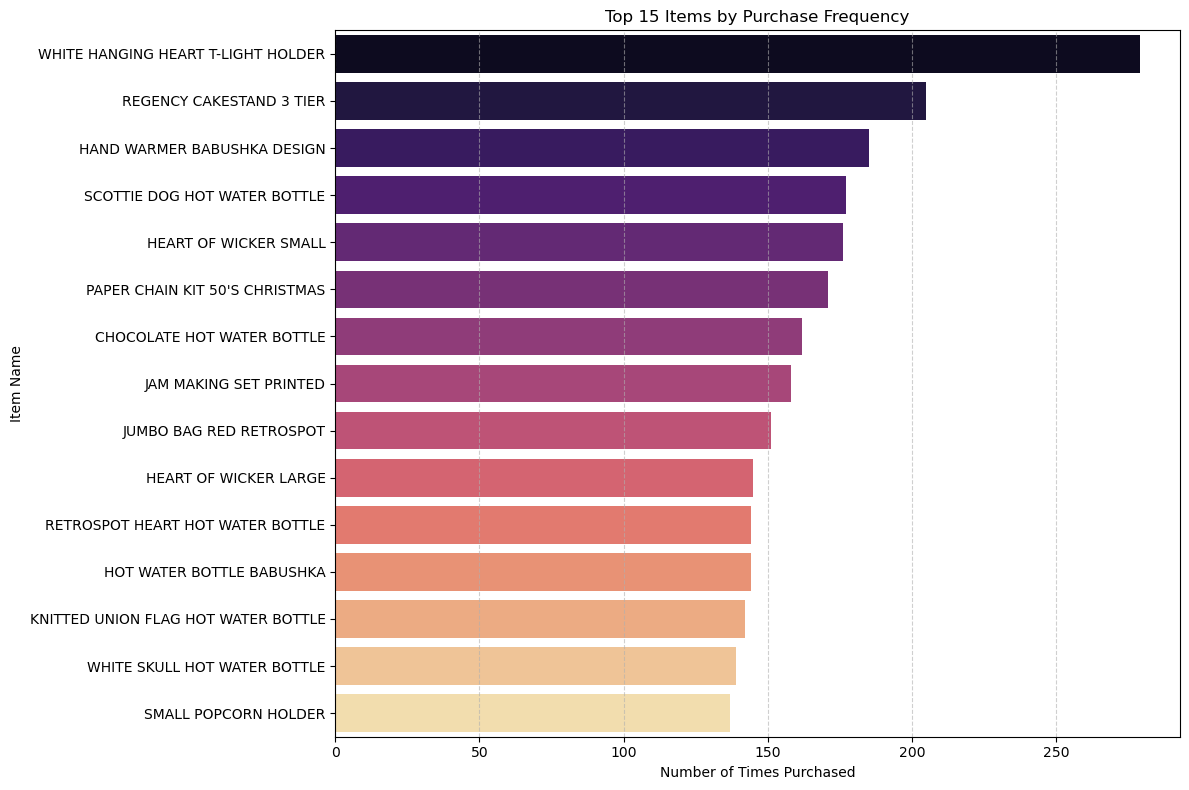

In [31]:
# Get the top 15 items
top_items = df_clean['Itemname'].value_counts().head(15)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x=top_items.values, y=top_items.index, hue=top_items.index, palette='magma',legend=False)

plt.title('Top 15 Items by Purchase Frequency')
plt.xlabel('Number of Times Purchased')
plt.ylabel('Item Name')
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [32]:
print("\n--- Top 10 countries ---")
display(df_clean['Country'].value_counts().head(10))


--- Top 10 countries ---


Country
United Kingdom    46624
Germany             760
France              650
Spain               266
Portugal            168
Norway              147
Belgium              95
Australia            80
Netherlands          72
Japan                65
Name: count, dtype: int64

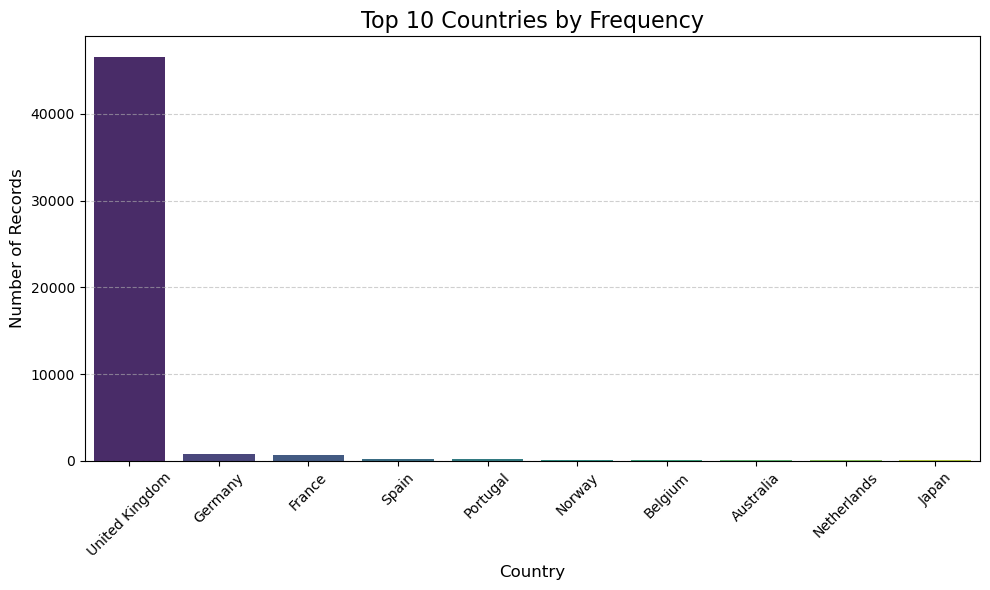

In [33]:
top_countries = df_clean['Country'].value_counts().head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.index, y=top_countries.values, hue=top_countries.index, palette='viridis')

plt.title('Top 10 Countries by Frequency', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45)  # rotate labels to avoid overlap
plt.tight_layout()
plt.show()

In [34]:
print("\n--- Number of unique bills (transactions) and unique items ---")
n_bills = df_clean['BillNo'].nunique()
n_items = df_clean['Itemname'].nunique()
print("Unique Bills:", n_bills)
print("Unique Items:", n_items)


--- Number of unique bills (transactions) and unique items ---
Unique Bills: 1805
Unique Items: 2791


In [35]:
print("\n--- Distribution of items per bill (cart size) ---")
items_per_bill = df_clean.groupby('BillNo')['Itemname'].nunique()
display(items_per_bill)
display(items_per_bill.describe())


--- Distribution of items per bill (cart size) ---


BillNo
536365      7
536366      2
536367     12
536368      4
536369      1
         ... 
540641     15
540642     50
540644     35
540645     13
540646    246
Name: Itemname, Length: 1805, dtype: int64

count    1805.000000
mean       26.934626
std        63.579778
min         1.000000
25%         5.000000
50%        14.000000
75%        27.000000
max       673.000000
Name: Itemname, dtype: float64

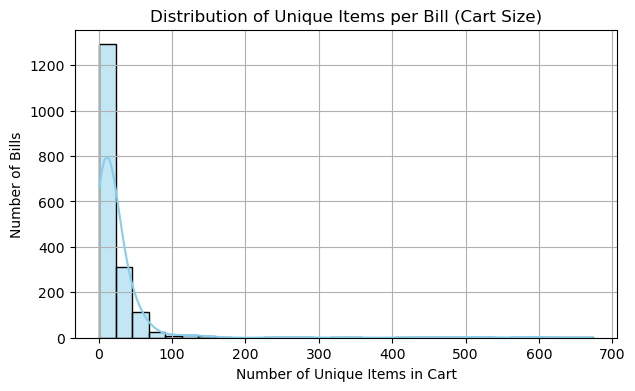

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4))
sns.histplot(items_per_bill, bins=30, kde=True, color='skyblue')
plt.title('Distribution of Unique Items per Bill (Cart Size)')
plt.xlabel('Number of Unique Items in Cart')
plt.ylabel('Number of Bills')
plt.grid(True)
plt.show()

In [37]:
x= df_clean['Itemname'].value_counts().sort_values(ascending=False)[:10]

In [38]:
x

Itemname
WHITE HANGING HEART T-LIGHT HOLDER    279
REGENCY CAKESTAND 3 TIER              205
HAND WARMER BABUSHKA DESIGN           185
SCOTTIE DOG HOT WATER BOTTLE          177
HEART OF WICKER SMALL                 176
PAPER CHAIN KIT 50'S CHRISTMAS        171
CHOCOLATE HOT WATER BOTTLE            162
JAM MAKING SET PRINTED                158
JUMBO BAG RED RETROSPOT               151
HEART OF WICKER LARGE                 145
Name: count, dtype: int64

In [39]:
!pip install mlxtend

It is an algorithm that uses frequent itemset to generate association rules. It is based on the concept that a subset of a frequent itemset must also be a frequent itemset.

In [41]:
import mlxtend
print(mlxtend.__version__)

0.23.4


Support : It is the frequency of item a or combination of item A and B.

Confidence: It tells us how often the items a and b occur given that a is bought.

Lift: It tells us the strength of the rule. 

Support = freq(A,B)/N

A and B  Products

N is total Transactions

Confidence = freq(A,B) / freq(A)
Lift = Support / support(A) * Support(B)

In [45]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

In [46]:
df_clean

,BillNo,Itemname,Quantity,Present_Date,Price,CustomerID,Country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...
49447,540646,CANDY SPOT CUSHION COVER,2,2011-01-10 14:32:00,3.36,0,United Kingdom
49448,540646,TOY TIDY PINK POLKADOT,1,2011-01-10 14:32:00,4.21,0,United Kingdom
49449,540646,MAGNETS PACK OF 4 RETRO PHOTO,2,2011-01-10 14:32:00,0.85,0,United Kingdom
49450,540646,BALLOON ART MAKE YOUR OWN FLOWERS,6,2011-01-10 14:32:00,1.66,0,United Kingdom


In [47]:
transactions =  df_clean.groupby(['BillNo','Itemname'])['Quantity'].sum().unstack().reset_index().set_index('BillNo')

In [48]:
transactions

Itemname,*Boombox Ipod Classic,*USB Office Mirror Ball,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,...,YULETIDE IMAGES GIFT WRAP SET,YULETIDE IMAGES S/6 PAPER BOXES,ZINC FINISH 15CM PLANTER POTS,ZINC FOLKART SLEIGH BELLS,ZINC HEART LATTICE CHARGER LARGE,ZINC HEART LATTICE CHARGER SMALL,ZINC HEART LATTICE T-LIGHT HOLDER,ZINC METAL HEART DECORATION,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK
BillNo,,,,,,,,,,,,,,,,,,,,,
536365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
536366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
536367,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
536368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
536369,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540641,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
540642,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
540644,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
transactions = transactions.fillna(0)


In [50]:
transactions

Itemname,*Boombox Ipod Classic,*USB Office Mirror Ball,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,...,YULETIDE IMAGES GIFT WRAP SET,YULETIDE IMAGES S/6 PAPER BOXES,ZINC FINISH 15CM PLANTER POTS,ZINC FOLKART SLEIGH BELLS,ZINC HEART LATTICE CHARGER LARGE,ZINC HEART LATTICE CHARGER SMALL,ZINC HEART LATTICE T-LIGHT HOLDER,ZINC METAL HEART DECORATION,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK
BillNo,,,,,,,,,,,,,,,,,,,,,
536365,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536366,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536367,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536368,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540641,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
540642,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
540644,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [51]:
def encode(x):
    if x <=0:
        return 0
    elif x>=0:
        return 1
basket = transactions.map(encode)

In [52]:
basket

Itemname,*Boombox Ipod Classic,*USB Office Mirror Ball,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,...,YULETIDE IMAGES GIFT WRAP SET,YULETIDE IMAGES S/6 PAPER BOXES,ZINC FINISH 15CM PLANTER POTS,ZINC FOLKART SLEIGH BELLS,ZINC HEART LATTICE CHARGER LARGE,ZINC HEART LATTICE CHARGER SMALL,ZINC HEART LATTICE T-LIGHT HOLDER,ZINC METAL HEART DECORATION,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK
BillNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540641,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
540642,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
540644,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [53]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
basket = basket.astype(bool)
frequent_itemset = apriori(basket,min_support=0.02,use_colnames=True)
rules = association_rules(frequent_itemset, metric="lift", min_threshold=1)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(12 PENCILS SMALL TUBE RED RETROSPOT),(12 PENCILS SMALL TUBE SKULL),0.033795,0.027701,0.020499,0.606557,21.896721,1.0,0.019562,2.471260,0.987711,0.500000,0.595348,0.673279
1,(12 PENCILS SMALL TUBE SKULL),(12 PENCILS SMALL TUBE RED RETROSPOT),0.027701,0.033795,0.020499,0.740000,21.896721,1.0,0.019562,3.716173,0.981520,0.500000,0.730906,0.673279
2,(PAPER CHAIN KIT 50'S CHRISTMAS),(6 RIBBONS RUSTIC CHARM),0.092521,0.049307,0.022715,0.245509,4.979143,1.0,0.018153,1.260045,0.880640,0.190698,0.206377,0.353092
3,(6 RIBBONS RUSTIC CHARM),(PAPER CHAIN KIT 50'S CHRISTMAS),0.049307,0.092521,0.022715,0.460674,4.979143,1.0,0.018153,1.682618,0.840611,0.190698,0.405688,0.353092
4,(REGENCY CAKESTAND 3 TIER),(6 RIBBONS RUSTIC CHARM),0.111357,0.049307,0.022161,0.199005,4.036000,1.0,0.016670,1.186889,0.846493,0.160000,0.157462,0.324222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
681,"(WHITE SKULL HOT WATER BOTTLE, RETROSPOT HEART...",(SCOTTIE DOG HOT WATER BOTTLE),0.028255,0.098061,0.021607,0.764706,7.798272,1.0,0.018836,3.833241,0.897114,0.206349,0.739124,0.492522
682,"(SCOTTIE DOG HOT WATER BOTTLE, WHITE SKULL HOT...",(RETROSPOT HEART HOT WATER BOTTLE),0.031025,0.077562,0.021607,0.696429,8.978954,1.0,0.019200,3.038618,0.917081,0.248408,0.670903,0.487500
683,(RETROSPOT HEART HOT WATER BOTTLE),"(SCOTTIE DOG HOT WATER BOTTLE, WHITE SKULL HOT...",0.077562,0.031025,0.021607,0.278571,8.978954,1.0,0.019200,1.343134,0.963348,0.248408,0.255473,0.487500
684,(SCOTTIE DOG HOT WATER BOTTLE),"(WHITE SKULL HOT WATER BOTTLE, RETROSPOT HEART...",0.098061,0.028255,0.021607,0.220339,7.798272,1.0,0.018836,1.246369,0.966547,0.206349,0.197669,0.492522


In [54]:
rules


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(12 PENCILS SMALL TUBE RED RETROSPOT),(12 PENCILS SMALL TUBE SKULL),0.033795,0.027701,0.020499,0.606557,21.896721,1.0,0.019562,2.471260,0.987711,0.500000,0.595348,0.673279
1,(12 PENCILS SMALL TUBE SKULL),(12 PENCILS SMALL TUBE RED RETROSPOT),0.027701,0.033795,0.020499,0.740000,21.896721,1.0,0.019562,3.716173,0.981520,0.500000,0.730906,0.673279
2,(PAPER CHAIN KIT 50'S CHRISTMAS),(6 RIBBONS RUSTIC CHARM),0.092521,0.049307,0.022715,0.245509,4.979143,1.0,0.018153,1.260045,0.880640,0.190698,0.206377,0.353092
3,(6 RIBBONS RUSTIC CHARM),(PAPER CHAIN KIT 50'S CHRISTMAS),0.049307,0.092521,0.022715,0.460674,4.979143,1.0,0.018153,1.682618,0.840611,0.190698,0.405688,0.353092
4,(REGENCY CAKESTAND 3 TIER),(6 RIBBONS RUSTIC CHARM),0.111357,0.049307,0.022161,0.199005,4.036000,1.0,0.016670,1.186889,0.846493,0.160000,0.157462,0.324222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
681,"(WHITE SKULL HOT WATER BOTTLE, RETROSPOT HEART...",(SCOTTIE DOG HOT WATER BOTTLE),0.028255,0.098061,0.021607,0.764706,7.798272,1.0,0.018836,3.833241,0.897114,0.206349,0.739124,0.492522
682,"(SCOTTIE DOG HOT WATER BOTTLE, WHITE SKULL HOT...",(RETROSPOT HEART HOT WATER BOTTLE),0.031025,0.077562,0.021607,0.696429,8.978954,1.0,0.019200,3.038618,0.917081,0.248408,0.670903,0.487500
683,(RETROSPOT HEART HOT WATER BOTTLE),"(SCOTTIE DOG HOT WATER BOTTLE, WHITE SKULL HOT...",0.077562,0.031025,0.021607,0.278571,8.978954,1.0,0.019200,1.343134,0.963348,0.248408,0.255473,0.487500
684,(SCOTTIE DOG HOT WATER BOTTLE),"(WHITE SKULL HOT WATER BOTTLE, RETROSPOT HEART...",0.098061,0.028255,0.021607,0.220339,7.798272,1.0,0.018836,1.246369,0.966547,0.206349,0.197669,0.492522


In [55]:
rules.to_excel(r"C:\Users\VIKAS\rules_output.xlsx", index=False)

In [56]:
rules.shape

(686, 14)

In [57]:
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(12 PENCILS SMALL TUBE RED RETROSPOT),(12 PENCILS SMALL TUBE SKULL),0.033795,0.027701,0.020499,0.606557,21.896721,1.0,0.019562,2.471260,0.987711,0.500000,0.595348,0.673279
1,(12 PENCILS SMALL TUBE SKULL),(12 PENCILS SMALL TUBE RED RETROSPOT),0.027701,0.033795,0.020499,0.740000,21.896721,1.0,0.019562,3.716173,0.981520,0.500000,0.730906,0.673279
2,(PAPER CHAIN KIT 50'S CHRISTMAS),(6 RIBBONS RUSTIC CHARM),0.092521,0.049307,0.022715,0.245509,4.979143,1.0,0.018153,1.260045,0.880640,0.190698,0.206377,0.353092
3,(6 RIBBONS RUSTIC CHARM),(PAPER CHAIN KIT 50'S CHRISTMAS),0.049307,0.092521,0.022715,0.460674,4.979143,1.0,0.018153,1.682618,0.840611,0.190698,0.405688,0.353092
4,(REGENCY CAKESTAND 3 TIER),(6 RIBBONS RUSTIC CHARM),0.111357,0.049307,0.022161,0.199005,4.036000,1.0,0.016670,1.186889,0.846493,0.160000,0.157462,0.324222


We filter rules to check lift and confidence. This part of the analysis is where the domain knowledge will come in handy. Since we do not have that, we'll just look for a couple of illustrative examples.We can filter the dataframe using standard pandas code. In this case, look for a large lift (1) and high confidence (.6)

In [59]:
a=rules[(rules['lift'] > 1) &
       (rules['confidence'] >= 0.6)]

In [60]:
a



,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(12 PENCILS SMALL TUBE RED RETROSPOT),(12 PENCILS SMALL TUBE SKULL),0.033795,0.027701,0.020499,0.606557,21.896721,1.0,0.019562,2.471260,0.987711,0.500000,0.595348,0.673279
1,(12 PENCILS SMALL TUBE SKULL),(12 PENCILS SMALL TUBE RED RETROSPOT),0.027701,0.033795,0.020499,0.740000,21.896721,1.0,0.019562,3.716173,0.981520,0.500000,0.730906,0.673279
19,(ALARM CLOCK BAKELIKE CHOCOLATE),(ALARM CLOCK BAKELIKE GREEN),0.024931,0.067590,0.021053,0.844444,12.493625,1.0,0.019368,5.994064,0.943481,0.294574,0.833168,0.577960
21,(ALARM CLOCK BAKELIKE IVORY),(ALARM CLOCK BAKELIKE GREEN),0.033795,0.067590,0.024377,0.721311,10.671862,1.0,0.022093,3.345706,0.937995,0.316547,0.701109,0.540984
23,(ALARM CLOCK BAKELIKE ORANGE),(ALARM CLOCK BAKELIKE GREEN),0.037119,0.067590,0.031579,0.850746,12.586861,1.0,0.029070,6.247147,0.956039,0.431818,0.839927,0.658980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671,(POPPY'S PLAYHOUSE LIVINGROOM),"(POPPY'S PLAYHOUSE BEDROOM, POPPY'S PLAYHOUSE ...",0.030471,0.029363,0.021053,0.690909,23.530017,1.0,0.020158,3.140297,0.987594,0.542857,0.681559,0.703945
675,"(SCOTTIE DOG HOT WATER BOTTLE, RED WOOLLY HOTT...",(RETROSPOT HEART HOT WATER BOTTLE),0.032133,0.077562,0.020499,0.637931,8.224754,1.0,0.018006,2.547685,0.907579,0.229814,0.607487,0.451108
676,"(RETROSPOT HEART HOT WATER BOTTLE, RED WOOLLY ...",(SCOTTIE DOG HOT WATER BOTTLE),0.025485,0.098061,0.020499,0.804348,8.202530,1.0,0.018000,4.609911,0.901049,0.198925,0.783076,0.506694
681,"(WHITE SKULL HOT WATER BOTTLE, RETROSPOT HEART...",(SCOTTIE DOG HOT WATER BOTTLE),0.028255,0.098061,0.021607,0.764706,7.798272,1.0,0.018836,3.833241,0.897114,0.206349,0.739124,0.492522


In [61]:
a.to_excel(r"C:\Users\VIKAS\rules_output.xlsx", index=False)